# Glioblastoma To AnnData

This notebook is set up to explore and assemble the contents of `data/glioblastoma-data` into a KaroSpace-ready `.h5ad`.

The critical constraint is the count matrix:

- `matrix.mtx` is very large
- a one-shot `mmread()` is not the safe default

So this workflow uses a streaming Matrix Market reader that writes shard `.h5ad` files and then concatenates them on disk.


In [15]:
from __future__ import annotations

import gc
import json
import os
from pathlib import Path

os.environ.setdefault("KMP_WARNINGS", "0")
os.environ.setdefault("NUMBA_DISABLE_JIT", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from anndata.experimental import concat_on_disk
from scipy import sparse

ad.settings.allow_write_nullable_strings = True

sns.set_theme(context="notebook", style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 60)

PROJECT_ROOT = Path("/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling")
ROOT = PROJECT_ROOT
DATA_DIR = PROJECT_ROOT / "data" / "glioblastoma-data"
BARCODES_PATH = DATA_DIR / "barcodes.tsv"
FEATURES_PATH = DATA_DIR / "features.tsv"
META_PATH = DATA_DIR / "meta.tsv"
VISIUM_COORDS_PATH = DATA_DIR / "Visium.coords.tsv.gz.tmp"
UMAP_COORDS_PATH = DATA_DIR / "UMAP.coords.tsv.gz.tmp"
MATRIX_PATH = DATA_DIR / "matrix.mtx"

OUTPUT_DIR = ROOT / "data" / "processed" / "glioblastoma"
SHARD_DIR = OUTPUT_DIR / "shards"
OUTPUT_PATH = OUTPUT_DIR / "glioblastoma.h5ad"

SHARD_N_CELLS = 2_000
MAX_CELLS = None
WRITE_SHARDS = True
CONCAT_SHARDS = True
ANALYSIS_INPUT_MODE = "reload_if_available"

ROOT, DATA_DIR.exists(), OUTPUT_PATH


(PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling'),
 True,
 PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/glioblastoma/glioblastoma.h5ad'))

## Load tables

These tables are small enough to inspect directly. The count matrix is handled separately.


In [16]:
def load_barcodes(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, sep="\t", header=None, names=["barcode"])


def load_features(path: Path) -> pd.DataFrame:
    out = pd.read_csv(path, sep="\t", header=None, names=["gene"])
    out["gene"] = out["gene"].astype("string")
    return out


def load_meta(path: Path) -> pd.DataFrame:
    out = pd.read_csv(path, sep="\t")
    out = out.rename(columns={"Unnamed: 0": "barcode"})
    out["barcode"] = out["barcode"].astype("string")
    return out


def load_coords(path: Path, x_name: str, y_name: str) -> pd.DataFrame:
    out = pd.read_csv(path, sep="\t", header=None, names=["barcode", x_name, y_name])
    out["barcode"] = out["barcode"].astype("string")
    out[x_name] = pd.to_numeric(out[x_name], errors="coerce").astype("float32")
    out[y_name] = pd.to_numeric(out[y_name], errors="coerce").astype("float32")
    return out


barcodes = load_barcodes(BARCODES_PATH)
features = load_features(FEATURES_PATH)
meta = load_meta(META_PATH)
visium = load_coords(VISIUM_COORDS_PATH, "x_visium", "y_visium")
umap = load_coords(UMAP_COORDS_PATH, "umap_1", "umap_2")

print("barcodes:", barcodes.shape)
print("features:", features.shape)
print("meta:", meta.shape)
print("visium:", visium.shape)
print("umap:", umap.shape)


barcodes: (115914, 1)
features: (27573, 1)
meta: (115914, 32)
visium: (115914, 3)
umap: (115914, 3)


In [17]:
print("barcodes aligned to meta:", barcodes["barcode"].equals(meta["barcode"]))
print("barcodes aligned to visium:", barcodes["barcode"].equals(visium["barcode"]))
print("barcodes aligned to umap:", barcodes["barcode"].equals(umap["barcode"]))

meta.head()


barcodes aligned to meta: False
barcodes aligned to visium: False
barcodes aligned to umap: False


,barcode,l2,l3,l4,orig.ident,nCount_Spatial,nFeature_Spatial,source,sample,Gender,Age,Diagnosis,short_histology,NF1,TP53,CDKN2A_B,PTEN,EGFR_PDGRA_MET,TERTp,ATRX,IDH1,KI67,MGMT,Level_1,AF_ivy,bc,inferCNV,AF_CNV,metaprogram,greenwald,AF,greenwald_metaprograms
0,AAACAAGTATCTCCCA-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1...,3_1,3_1_2,3_1_2_1,SNU38A,4414,2831,FFPE,SNU38,Male,27,Normal brain (from central neurocytoma),Normal brain,NaN,NaN,NaN,NaN,NaN,WT,WT,WT,NaN,NaN,3,LE_WGM,AAACAAGTATCTCCCA-1,43.552852,LE,LE_WM,L5,LE_WM,Oligo
1,AAACACCAATAACTGC-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1...,2_1,2_1_1,2_1_1_1,SNU38A,2738,1783,FFPE,SNU38,Male,27,Normal brain (from central neurocytoma),Normal brain,NaN,NaN,NaN,NaN,NaN,WT,WT,WT,NaN,NaN,2,LE_WM,AAACACCAATAACTGC-1,81.755496,LE,LE_WM,L4,LE_WM,Oligo
2,AAACATTTCCCGGATT-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1...,3_1,3_1_3,3_1_3_1,SNU38A,4212,2820,FFPE,SNU38,Male,27,Normal brain (from central neurocytoma),Normal brain,NaN,NaN,NaN,NaN,NaN,WT,WT,WT,NaN,NaN,3,LE_WGM,AAACATTTCCCGGATT-1,46.517996,LE,LE_WM,L5,LE_GM,AC (malig.)
3,AAACCTCATGAAGTTG-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1...,1_1,1_1_3,1_1_3_1,SNU38A,2355,1534,FFPE,SNU38,Male,27,Normal brain (from central neurocytoma),Normal brain,NaN,NaN,NaN,NaN,NaN,WT,WT,WT,NaN,NaN,1,LE_WM,AAACCTCATGAAGTTG-1,59.049449,LE,LE_WM,L4,LE_WM,Oligo
4,AAACGGGCGTACGGGT-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1...,3_2,3_2_1,3_2_1_3,SNU38A,4636,3074,FFPE,SNU38,Male,27,Normal brain (from central neurocytoma),Normal brain,NaN,NaN,NaN,NaN,NaN,WT,WT,WT,NaN,NaN,3,LE_GM,AAACGGGCGTACGGGT-1,53.788779,LE,LE_GM,L5,LE_GM,Oligo


In [18]:
summary_cols = [
    "orig.ident",
    "sample",
    "source",
    "Diagnosis",
    "short_histology",
    "Level_1",
    "greenwald_metaprograms",
    "AF",
    "nCount_Spatial",
    "nFeature_Spatial",
]

meta[summary_cols].describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
orig.ident,115914,32,SNU22A,4907,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sample,115914,17,SNU21,19275,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,115914,2,FFPE,99974,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diagnosis,115914,4,Glioblastoma multiforme,100488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
short_histology,115914,4,GBM,100488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Level_1,115914.0,NaN,NaN,NaN,2.163578,1.191011,1.0,1.0,2.0,3.0,7.0
greenwald_metaprograms,115914,11,Oligo,34286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AF,115914,10,IT,24782,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nCount_Spatial,115914.0,NaN,NaN,NaN,12170.329201,7874.303298,2001.0,6154.0,10361.0,16385.0,91012.0
nFeature_Spatial,115914.0,NaN,NaN,NaN,4707.486119,1781.089249,815.0,3332.0,4694.0,6011.0,10699.0


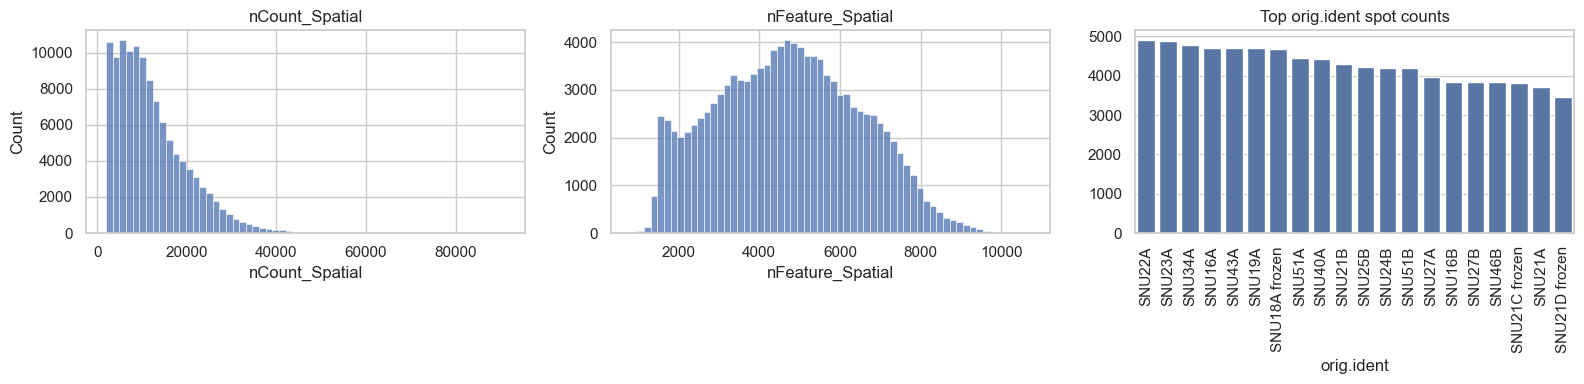

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(meta["nCount_Spatial"], bins=60, ax=axes[0])
axes[0].set_title("nCount_Spatial")

sns.histplot(meta["nFeature_Spatial"], bins=60, ax=axes[1])
axes[1].set_title("nFeature_Spatial")

sample_sizes = meta["orig.ident"].value_counts().head(20)
sns.barplot(x=sample_sizes.index, y=sample_sizes.values, ax=axes[2], color="#4c72b0")
axes[2].set_title("Top orig.ident spot counts")
axes[2].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


## Prepare compact `obs` and `var`

`orig.ident` is a good default `section_id` here because it splits the data into natural sample-level panels.


In [20]:
OBS_COLUMNS = [
    "barcode",
    "orig.ident",
    "sample",
    "source",
    "Gender",
    "Age",
    "Diagnosis",
    "short_histology",
    "Level_1",
    "AF_ivy",
    "inferCNV",
    "AF_CNV",
    "metaprogram",
    "greenwald",
    "AF",
    "greenwald_metaprograms",
    "nCount_Spatial",
    "nFeature_Spatial",
]

CATEGORY_COLUMNS = [
    "orig.ident",
    "sample",
    "source",
    "Gender",
    "Diagnosis",
    "short_histology",
    "Level_1",
    "AF_ivy",
    "AF_CNV",
    "metaprogram",
    "greenwald",
    "AF",
    "greenwald_metaprograms",
]


def sanitize_obs_for_h5ad(obs_df: pd.DataFrame) -> pd.DataFrame:
    out = obs_df.copy()
    for col in out.columns:
        ser = out[col]
        if isinstance(ser.dtype, pd.CategoricalDtype):
            continue
        if pd.api.types.is_object_dtype(ser) or pd.api.types.is_string_dtype(ser):
            out[col] = ser.astype("string")
    return out


def prepare_obs_table(
    barcodes_df: pd.DataFrame,
    meta_df: pd.DataFrame,
    visium_df: pd.DataFrame,
    umap_df: pd.DataFrame,
) -> pd.DataFrame:
    obs = barcodes_df.copy()
    obs = obs.merge(meta_df[OBS_COLUMNS], on="barcode", how="left", validate="one_to_one")
    obs = obs.merge(visium_df, on="barcode", how="left", validate="one_to_one")
    obs = obs.merge(umap_df, on="barcode", how="left", validate="one_to_one")

    obs["dataset_id"] = pd.Categorical(["glioblastoma"] * len(obs))
    obs["sample_id"] = obs["sample"].astype("string").fillna("unknown").astype("category")
    obs["section_id"] = obs["orig.ident"].astype("string").fillna("unknown").astype("category")

    obs["Age"] = pd.to_numeric(obs["Age"], errors="coerce").astype("float32")
    obs["nCount_Spatial"] = pd.to_numeric(obs["nCount_Spatial"], errors="coerce").astype("Int32")
    obs["nFeature_Spatial"] = pd.to_numeric(obs["nFeature_Spatial"], errors="coerce").astype("Int32")
    obs["inferCNV"] = pd.to_numeric(obs["inferCNV"], errors="coerce").astype("float32")

    for col in CATEGORY_COLUMNS + ["dataset_id", "sample_id", "section_id"]:
        if col in obs.columns:
            obs[col] = obs[col].astype("category")

    obs = sanitize_obs_for_h5ad(obs)
    return obs.set_index("barcode", drop=True)


def prepare_var_table(features_df: pd.DataFrame) -> pd.DataFrame:
    genes = pd.Index(features_df["gene"].astype(str), name="gene")
    if not genes.is_unique:
        seen: dict[str, int] = {}
        deduped = []
        for gene in genes:
            count = seen.get(gene, 0)
            deduped.append(gene if count == 0 else f"{gene}-{count}")
            seen[gene] = count + 1
        genes = pd.Index(deduped, name="gene")
    var = pd.DataFrame(index=genes)
    return var


obs = prepare_obs_table(barcodes, meta, visium, umap)
var = prepare_var_table(features)

obs.shape, var.shape


((115914, 24), (27573, 0))

In [21]:
obs.head()


,orig.ident,sample,source,Gender,Age,Diagnosis,short_histology,Level_1,AF_ivy,inferCNV,AF_CNV,metaprogram,greenwald,AF,greenwald_metaprograms,nCount_Spatial,nFeature_Spatial,x_visium,y_visium,umap_1,umap_2,dataset_id,sample_id,section_id
barcode,,,,,,,,,,,,,,,,,,,,,,,,
AAACAAGTATCTCCCA-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,SNU38A,SNU38,FFPE,Male,27.0,Normal brain (from central neurocytoma),Normal brain,3,LE_WGM,43.552853,LE,LE_WM,L5,LE_WM,Oligo,4414,2831,102.0,273.0,-1.764052,-6.410627,glioblastoma,SNU38,SNU38A
AAACACCAATAACTGC-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,SNU38A,SNU38,FFPE,Male,27.0,Normal brain (from central neurocytoma),Normal brain,2,LE_WM,81.755493,LE,LE_WM,L4,LE_WM,Oligo,2738,1783,19.0,264.0,-0.705961,4.055656,glioblastoma,SNU38,SNU38A
AAACATTTCCCGGATT-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,SNU38A,SNU38,FFPE,Male,27.0,Normal brain (from central neurocytoma),Normal brain,3,LE_WGM,46.517998,LE,LE_WM,L5,LE_GM,AC (malig.),4212,2820,97.0,262.0,-1.790937,-7.272305,glioblastoma,SNU38,SNU38A
AAACCTCATGAAGTTG-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,SNU38A,SNU38,FFPE,Male,27.0,Normal brain (from central neurocytoma),Normal brain,1,LE_WM,59.049450,LE,LE_WM,L4,LE_WM,Oligo,2355,1534,19.0,286.0,0.100493,-0.673676,glioblastoma,SNU38,SNU38A
AAACGGGCGTACGGGT-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,SNU38A,SNU38,FFPE,Male,27.0,Normal brain (from central neurocytoma),Normal brain,3,LE_GM,53.788780,LE,LE_GM,L5,LE_GM,Oligo,4636,3074,91.0,258.0,-2.769087,-8.531202,glioblastoma,SNU38,SNU38A


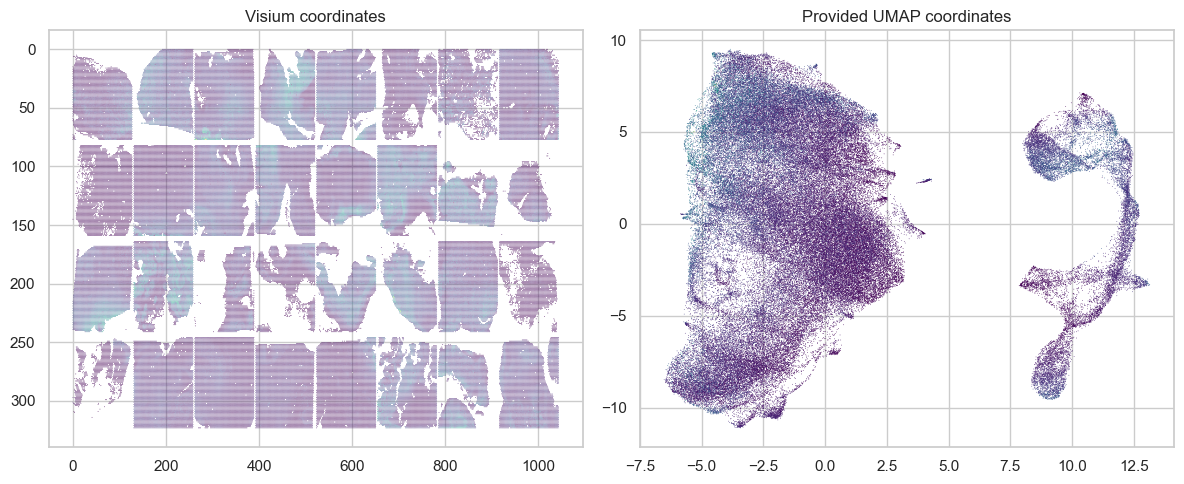

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(obs["x_visium"], obs["y_visium"], s=0.3, c=obs["nCount_Spatial"].astype(float), cmap="viridis", linewidths=0)
axes[0].set_title("Visium coordinates")
axes[0].invert_yaxis()

axes[1].scatter(obs["umap_1"], obs["umap_2"], s=0.3, c=obs["nCount_Spatial"].astype(float), cmap="viridis", linewidths=0)
axes[1].set_title("Provided UMAP coordinates")

plt.tight_layout()
plt.show()


## Streaming Matrix Market assembly

The matrix dimensions are read from the Matrix Market header. Then the file is streamed column-block by column-block into shard `.h5ad` files.

This avoids holding the full `115,914 x 27,573` sparse matrix in memory at once.


In [23]:
def read_matrix_market_shape(path: Path) -> tuple[int, int, int]:
    with path.open("rt") as handle:
        header = handle.readline().strip()
        if not header.startswith("%%MatrixMarket matrix coordinate"):
            raise ValueError(f"unexpected Matrix Market header: {header}")

        line = handle.readline().strip()
        while line.startswith("%") or not line:
            line = handle.readline().strip()

    n_rows, n_cols, nnz = map(int, line.split())
    return n_rows, n_cols, nnz


def write_matrix_market_shards(
    matrix_path: Path,
    obs_df: pd.DataFrame,
    var_df: pd.DataFrame,
    shard_dir: Path,
    *,
    shard_n_cells: int = 2_000,
    max_cells: int | None = None,
    value_dtype=np.float32,
) -> list[Path]:
    n_genes, n_cells_total, nnz = read_matrix_market_shape(matrix_path)
    if n_genes != var_df.shape[0]:
        raise ValueError(f"matrix rows {n_genes} != var rows {var_df.shape[0]}")
    if n_cells_total != obs_df.shape[0]:
        raise ValueError(f"matrix cols {n_cells_total} != obs rows {obs_df.shape[0]}")

    target_cells = min(n_cells_total, max_cells) if max_cells is not None else n_cells_total
    shard_dir.mkdir(parents=True, exist_ok=True)

    shard_paths: list[Path] = []
    current_start = 1
    current_end = min(shard_n_cells, target_cells)
    row_idx: list[int] = []
    col_idx: list[int] = []
    values: list[float] = []
    prev_col = 1

    def flush_shard(start_col: int, end_col: int, shard_idx: int) -> Path:
        n_obs = end_col - start_col + 1
        X = sparse.csr_matrix(
            (
                np.asarray(values, dtype=value_dtype),
                (
                    np.asarray(row_idx, dtype=np.int32),
                    np.asarray(col_idx, dtype=np.int32),
                ),
            ),
            shape=(n_obs, var_df.shape[0]),
        )

        shard_obs = obs_df.iloc[start_col - 1:end_col].copy()
        shard = ad.AnnData(X=X, obs=shard_obs, var=var_df.copy())
        shard.obsm["spatial"] = shard_obs[["x_visium", "y_visium"]].to_numpy(dtype=np.float32)
        shard.obsm["X_umap"] = shard_obs[["umap_1", "umap_2"]].to_numpy(dtype=np.float32)

        shard_path = shard_dir / f"glioblastoma_shard_{shard_idx:03d}.h5ad"
        shard.write_h5ad(shard_path)
        del shard, shard_obs, X
        gc.collect()
        return shard_path

    with matrix_path.open("rt") as handle:
        _ = handle.readline()
        line = handle.readline().strip()
        while line.startswith("%") or not line:
            line = handle.readline().strip()

        for raw in handle:
            parts = raw.split()
            if not parts:
                continue

            gene_1based = int(parts[0])
            cell_1based = int(parts[1])
            value = float(parts[2])

            if cell_1based < prev_col:
                raise ValueError("matrix columns are not nondecreasing; streaming assumption failed")
            prev_col = cell_1based

            if cell_1based > target_cells:
                break

            while cell_1based > current_end:
                shard_idx = len(shard_paths) + 1
                shard_paths.append(flush_shard(current_start, current_end, shard_idx))
                row_idx.clear()
                col_idx.clear()
                values.clear()
                current_start = current_end + 1
                current_end = min(current_start + shard_n_cells - 1, target_cells)

            row_idx.append(cell_1based - current_start)
            col_idx.append(gene_1based - 1)
            values.append(value)

    if current_start <= target_cells:
        shard_idx = len(shard_paths) + 1
        shard_paths.append(flush_shard(current_start, current_end, shard_idx))

    return shard_paths


def concat_shards(shard_paths: list[Path], output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    concat_on_disk(
        shard_paths,
        output_path,
        axis=0,
        join="inner",
        merge="same",
        uns_merge="same",
        max_loaded_elems=100_000_000,
    )


matrix_shape = read_matrix_market_shape(MATRIX_PATH)
matrix_shape


(27573, 115914, 545660369)

In [24]:
print("matrix rows (genes):", matrix_shape[0])
print("matrix cols (cells):", matrix_shape[1])
print("matrix nnz:", matrix_shape[2])
print("assembly mode: sparse CSR shards + on-disk concat")


matrix rows (genes): 27573
matrix cols (cells): 115914
matrix nnz: 545660369
assembly mode: sparse CSR shards + on-disk concat


## Build shards

This notebook is configured for the full dataset by default:

- `MAX_CELLS = None`
- `WRITE_SHARDS = True`
- `CONCAT_SHARDS = True`

The count matrix is kept sparse throughout the assembly path.


In [25]:
if WRITE_SHARDS:
    shard_paths = write_matrix_market_shards(
        MATRIX_PATH,
        obs,
        var,
        SHARD_DIR,
        shard_n_cells=SHARD_N_CELLS,
        max_cells=MAX_CELLS,
    )
    print(f"wrote {len(shard_paths)} shards to {SHARD_DIR}")
else:
    shard_paths = sorted(SHARD_DIR.glob('glioblastoma_shard_*.h5ad'))
    print("WRITE_SHARDS is False")
    print(f"existing shards: {len(shard_paths)}")

shard_paths[:5]


wrote 58 shards to /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/glioblastoma/shards


[PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/glioblastoma/shards/glioblastoma_shard_001.h5ad'),
 PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/glioblastoma/shards/glioblastoma_shard_002.h5ad'),
 PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/glioblastoma/shards/glioblastoma_shard_003.h5ad'),
 PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/glioblastoma/shards/glioblastoma_shard_004.h5ad'),
 PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/glioblastoma/shards/glioblastoma_shard_005.h5ad')]

In [26]:
if CONCAT_SHARDS:
    if not shard_paths:
        raise RuntimeError("no shards available to concatenate")
    concat_shards(shard_paths, OUTPUT_PATH)
    print(f"Wrote concatenated h5ad: {OUTPUT_PATH}")
else:
    print("CONCAT_SHARDS is False")
    print(f"planned output: {OUTPUT_PATH}")


Wrote concatenated h5ad: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/glioblastoma/glioblastoma.h5ad


## Reload assembled data

Once the output file exists, use this reload path for exploration instead of rebuilding.


In [27]:
if ANALYSIS_INPUT_MODE not in {"reload_if_available", "reload_only", "memory_only"}:
    raise ValueError("ANALYSIS_INPUT_MODE must be one of: reload_if_available, reload_only, memory_only")

if ANALYSIS_INPUT_MODE in {"reload_if_available", "reload_only"} and OUTPUT_PATH.exists():
    adata = ad.read_h5ad(OUTPUT_PATH)
    adata_source = f"reloaded from {OUTPUT_PATH}"
elif ANALYSIS_INPUT_MODE == "reload_only":
    raise FileNotFoundError(f"requested reload_only, but no file exists at {OUTPUT_PATH}")
else:
    adata = None
    adata_source = "no assembled h5ad loaded"

print(adata_source)
adata


reloaded from /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/glioblastoma/glioblastoma.h5ad


AnnData object with n_obs × n_vars = 115914 × 27573
    obs: 'orig.ident', 'sample', 'source', 'Gender', 'Age', 'Diagnosis', 'short_histology', 'Level_1', 'AF_ivy', 'inferCNV', 'AF_CNV', 'metaprogram', 'greenwald', 'AF', 'greenwald_metaprograms', 'nCount_Spatial', 'nFeature_Spatial', 'x_visium', 'y_visium', 'umap_1', 'umap_2', 'dataset_id', 'sample_id', 'section_id'
    obsm: 'X_umap', 'spatial'

In [28]:
if adata is not None:
    print("obs x vars:", adata.n_obs, adata.n_vars)
    print("obsm keys:", list(adata.obsm.keys()))
    print("obs columns:", len(adata.obs.columns))
    print("var columns:", len(adata.var.columns))
    adata.obs.head()


obs x vars: 115914 27573
obsm keys: ['X_umap', 'spatial']
obs columns: 24
var columns: 0


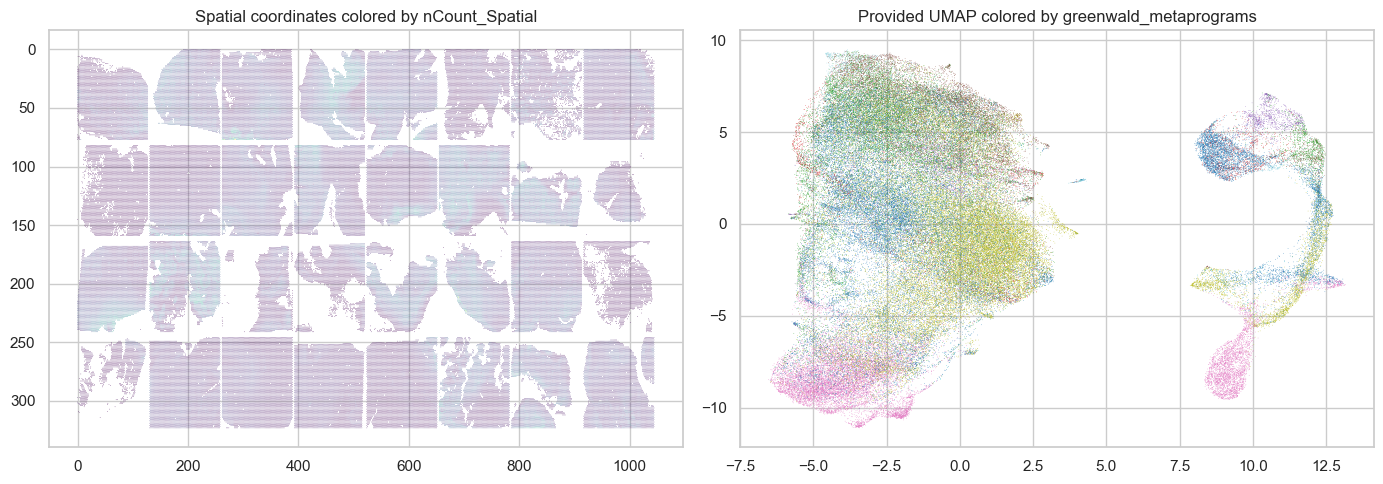

In [29]:
if adata is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(
        adata.obsm["spatial"][:, 0],
        adata.obsm["spatial"][:, 1],
        s=0.2,
        c=adata.obs["nCount_Spatial"].astype(float).to_numpy(),
        cmap="viridis",
        linewidths=0,
    )
    axes[0].set_title("Spatial coordinates colored by nCount_Spatial")
    axes[0].invert_yaxis()

    color_codes = adata.obs["greenwald_metaprograms"].astype("category").cat.codes.to_numpy()
    axes[1].scatter(
        adata.obsm["X_umap"][:, 0],
        adata.obsm["X_umap"][:, 1],
        s=0.2,
        c=color_codes,
        cmap="tab20",
        linewidths=0,
    )
    axes[1].set_title("Provided UMAP colored by greenwald_metaprograms")

    plt.tight_layout()
    plt.show()


In [30]:
karospace_summary = {
    "output_path": str(OUTPUT_PATH),
    "section_key": "section_id",
    "sample_key": "sample_id",
    "spatial_key": "obsm['spatial']",
    "umap_key": "obsm['X_umap']",
    "primary_color_candidates": [
        "greenwald_metaprograms",
        "AF",
        "short_histology",
        "source",
    ],
    "metadata_columns": [
        "orig.ident",
        "sample",
        "source",
        "Diagnosis",
        "short_histology",
        "Level_1",
        "AF",
        "greenwald_metaprograms",
    ],
}

print(json.dumps(karospace_summary, indent=2))


{
  "output_path": "/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/glioblastoma/glioblastoma.h5ad",
  "section_key": "section_id",
  "sample_key": "sample_id",
  "spatial_key": "obsm['spatial']",
  "umap_key": "obsm['X_umap']",
  "primary_color_candidates": [
    "greenwald_metaprograms",
    "AF",
    "short_histology",
    "source"
  ],
  "metadata_columns": [
    "orig.ident",
    "sample",
    "source",
    "Diagnosis",
    "short_histology",
    "Level_1",
    "AF",
    "greenwald_metaprograms"
  ]
}


In [36]:
adata.obs

,orig.ident,sample,source,Gender,Age,Diagnosis,short_histology,Level_1,AF_ivy,inferCNV,AF_CNV,metaprogram,greenwald,AF,greenwald_metaprograms,nCount_Spatial,nFeature_Spatial,x_visium,y_visium,umap_1,umap_2,dataset_id,sample_id,section_id
AAACAAGTATCTCCCA-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,SNU38A,SNU38,FFPE,Male,27.0,Normal brain (from central neurocytoma),Normal brain,3,LE_WGM,43.552853,LE,LE_WM,L5,LE_WM,Oligo,4414,2831,102.0,273.0,-1.764052,-6.410627,glioblastoma,SNU38,SNU38A
AAACACCAATAACTGC-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,SNU38A,SNU38,FFPE,Male,27.0,Normal brain (from central neurocytoma),Normal brain,2,LE_WM,81.755493,LE,LE_WM,L4,LE_WM,Oligo,2738,1783,19.0,264.0,-0.705961,4.055656,glioblastoma,SNU38,SNU38A
AAACATTTCCCGGATT-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,SNU38A,SNU38,FFPE,Male,27.0,Normal brain (from central neurocytoma),Normal brain,3,LE_WGM,46.517998,LE,LE_WM,L5,LE_GM,AC (malig.),4212,2820,97.0,262.0,-1.790937,-7.272305,glioblastoma,SNU38,SNU38A
AAACCTCATGAAGTTG-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,SNU38A,SNU38,FFPE,Male,27.0,Normal brain (from central neurocytoma),Normal brain,1,LE_WM,59.049450,LE,LE_WM,L4,LE_WM,Oligo,2355,1534,19.0,286.0,0.100493,-0.673676,glioblastoma,SNU38,SNU38A
AAACGGGCGTACGGGT-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,SNU38A,SNU38,FFPE,Male,27.0,Normal brain (from central neurocytoma),Normal brain,3,LE_GM,53.788780,LE,LE_GM,L5,LE_GM,Oligo,4636,3074,91.0,258.0,-2.769087,-8.531202,glioblastoma,SNU38,SNU38A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTTCACATCCAGG-1_2,SNU34A,SNU34,FFPE,Female,66.0,Glioblastoma multiforme,GBM,2,CT,218.215927,CT,CT,L4,CT,AC (malig.),9231,4485,959.0,19.0,0.897978,4.266138,glioblastoma,SNU34,SNU34A
TTGTTTCATTAGTCTA-1_2,SNU34A,SNU34,FFPE,Female,66.0,Glioblastoma multiforme,GBM,1,CT,223.839035,CT,CT,L4,CT,AC (malig.),9213,4417,947.0,17.0,-2.222476,-1.956603,glioblastoma,SNU34,SNU34A
TTGTTTCCATACAACT-1_2,SNU34A,SNU34,FFPE,Female,66.0,Glioblastoma multiforme,GBM,3,LE_WGM,129.083328,IT,IT,L5,IT,Neuron,10798,5066,944.0,32.0,-6.104200,-9.035285,glioblastoma,SNU34,SNU34A
TTGTTTGTATTACACG-1_2,SNU34A,SNU34,FFPE,Female,66.0,Glioblastoma multiforme,GBM,2,CT,243.103302,CT,CT,L4,CT,AC (malig.),7569,4012,958.0,4.0,0.416210,5.704171,glioblastoma,SNU34,SNU34A
